<a href="https://colab.research.google.com/github/GabriellaJovanka/depresi-mahasiswa-app/blob/main/FT_guweh_sendiri.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **DETEKSI TINGKAT DEPRESI PADA MAHASISWA**

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder, OrdinalEncoder, LabelEncoder

In [ ]:
df = pd.read_csv("Bengkod-Depresi.csv")

In [ ]:
print("\nNama kolom saat ini:\n")
print(df.columns)


Nama kolom saat ini:

Index(['id', 'Gender', 'Age', 'City', 'Profession', 'Academic Pressure',
       'Work Pressure', 'CGPA', 'Study Satisfaction', 'Job Satisfaction',
       'Sleep Duration', 'Dietary Habits', 'Degree',
       'Have you ever had suicidal thoughts ?', 'Work/Study Hours',
       'Financial Stress', 'Family History of Mental Illness', 'Depression'],
      dtype='object')


In [ ]:
# Menampilkan 5 data pertama dan terakhir
# print(df.head())
df.head()

,id,Gender,Age,City,Profession,Academic Pressure,Work Pressure,CGPA,Study Satisfaction,Job Satisfaction,Sleep Duration,Dietary Habits,Degree,Have you ever had suicidal thoughts ?,Work/Study Hours,Financial Stress,Family History of Mental Illness,Depression
0,2,Male,33,Visakhapatnam,Student,5,0,8.97,2,0,5-6 hours,Healthy,B.Pharm,Yes,3,1.0,No,1.0
1,8,Female,24,Bangalore,Student,2,0,5.90,5,0,5-6 hours,Moderate,BSc,No,3,2.0,Yes,0.0
2,26,Male,31,Srinagar,Student,3,0,7.03,5,0,Less than 5 hours,Healthy,BA,No,9,1.0,Yes,0.0
3,30,Female,28,Varanasi,Student,3,0,5.59,2,0,7-8 hours,Moderate,BCA,Yes,4,5.0,Yes,1.0
4,32,Female,25,Jaipur,Student,4,0,8.13,3,0,5-6 hours,Moderate,M.Tech,Yes,1,1.0,No,0.0


In [ ]:
df.tail()

,id,Gender,Age,City,Profession,Academic Pressure,Work Pressure,CGPA,Study Satisfaction,Job Satisfaction,Sleep Duration,Dietary Habits,Degree,Have you ever had suicidal thoughts ?,Work/Study Hours,Financial Stress,Family History of Mental Illness,Depression
28003,103,Female,19,Kalyan,Student,5,0,5.64,5,0,Less than 5 hours,Moderate,Class 12,Yes,4,5.0,Yes,1.0
28004,106,Male,29,Srinagar,Student,3,0,8.58,3,0,More than 8 hours,Moderate,M.Tech,Yes,10,2.0,Yes,1.0
28005,120,Male,25,Nashik,Student,5,0,6.51,2,0,Less than 5 hours,Unhealthy,M.Ed,Yes,2,5.0,Yes,1.0
28006,132,Female,20,Ahmedabad,Student,5,0,7.25,3,0,5-6 hours,Healthy,Class 12,Yes,10,3.0,No,1.0
28007,139,Male,19,Chennai,Student,2,0,7.83,2,0,7-8 hours,Unhealthy,Class 12,No,6,3.0,No,0.0


In [ ]:
df.describe()

,id,Age,Academic Pressure,Work Pressure,CGPA,Study Satisfaction,Job Satisfaction,Work/Study Hours,Financial Stress,Depression
count,28008.000000,28008.000000,28008.000000,28008.000000,28008.000000,28008.000000,28008.000000,28008.000000,27963.000000,27966.000000
mean,70613.609933,25.824264,3.141245,0.000428,7.655372,2.944337,0.000678,7.154456,3.139077,0.585354
std,40792.430225,4.903456,1.380940,0.043908,1.470506,1.361318,0.044310,3.708348,1.437839,0.492670
min,2.000000,18.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000
25%,35075.500000,21.000000,2.000000,0.000000,6.287500,2.000000,0.000000,4.000000,2.000000,0.000000
50%,70855.000000,25.000000,3.000000,0.000000,7.770000,3.000000,0.000000,8.000000,3.000000,1.000000
75%,106075.750000,30.000000,4.000000,0.000000,8.920000,4.000000,0.000000,10.000000,4.000000,1.000000
max,141248.000000,59.000000,5.000000,5.000000,10.000000,5.000000,4.000000,12.000000,5.000000,1.000000


In [ ]:
# Memeriksa informasi tipe data dan missing value
print("\nInformasi Tipe Data:\n")
df.info()



Informasi Tipe Data:

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 28008 entries, 0 to 28007
Data columns (total 18 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   id                                     28008 non-null  int64  
 1   Gender                                 28008 non-null  object 
 2   Age                                    28008 non-null  int64  
 3   City                                   28008 non-null  object 
 4   Profession                             28008 non-null  object 
 5   Academic Pressure                      28008 non-null  int64  
 6   Work Pressure                          28008 non-null  int64  
 7   CGPA                                   28008 non-null  float64
 8   Study Satisfaction                     28008 non-null  int64  
 9   Job Satisfaction                       28008 non-null  int64  
 10  Sleep Duration                         28008 no

In [ ]:
print("\nData duplikat: \n")
df.isna().sum()


Data duplikat: 



,0
id,0
Gender,0
Age,0
City,0
Profession,0
Academic Pressure,0
Work Pressure,0
CGPA,0
Study Satisfaction,0
Job Satisfaction,0


In [ ]:
# Memeriksa duplikasi data
print(f"Jumlah data duplikat: {df.duplicated().sum()}")

Jumlah data duplikat: 46


/tmp/ipykernel_3797/1749714106.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Depression', data=df, palette='viridis')


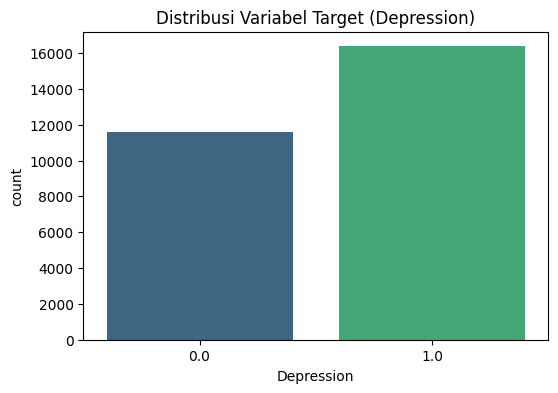

In [ ]:
# Distribusi target
plt.figure(figsize=(6,4))
sns.countplot(x='Depression', data=df, palette='viridis')
plt.title('Distribusi Variabel Target (Depression)')
plt.show()

# Insight: Jika jumlah 'Yes' dan 'No' sangat jauh berbeda, data mengalami imbalance dan butuh penanganan saat modeling.

Dari grafik distribusi, jumlah mahasiswa yang terindikasi depresi (Label 1.0) menyentuh angka lebih dari 16.000, sedangkan yang tidak depresi (Label 0.0) hanya sekitar 11.000-an.

Karena data tidak seimbang, model AI bisa jadi "malas" dan memprediksi semua orang "Depresi" agar skornya terlihat tinggi. Keputusannya, pada tahap modeling nanti, kita harus menggunakan teknik penyeimbang atau mengevaluasi model tidak hanya dari "Akurasi" saja, tapi juga seberapa tepat dia mengenali kelas yang minoritas.

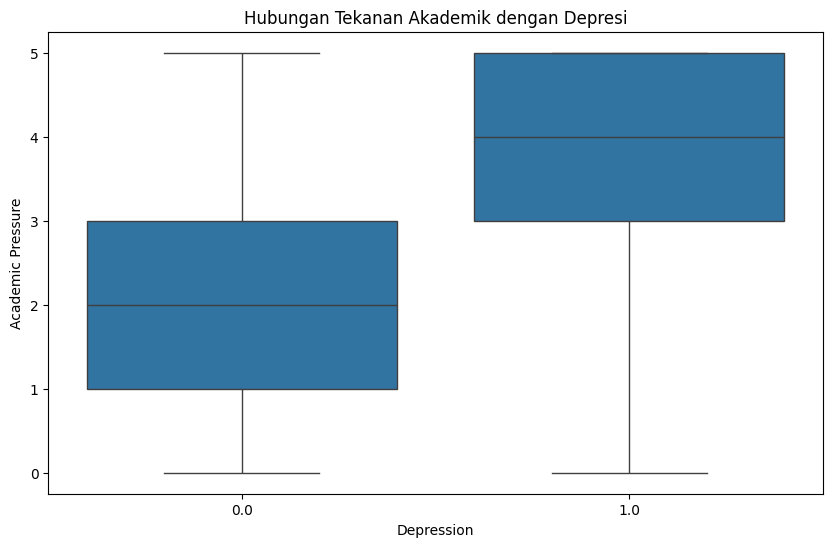

In [ ]:
# Hubungan Tekanan Akademik vs Depresi
plt.figure(figsize=(10, 6))
sns.boxplot(x='Depression', y='Academic Pressure', data=df)
plt.title('Hubungan Tekanan Akademik dengan Depresi')
plt.show()

# Insight: Jika median tekanan akademik penderita depresi jauh lebih tinggi,
# maka fitur ini adalah prediktor utama. Keputusan: Fitur ini wajib masuk model.

Pola: Dari grafik boxplot "Academic Pressure", terlihat jelas bahwa mahasiswa yang tingkat stres akademiknya tinggi (di angka 4 hingga 5) sangat mendominasi kelompok mahasiswa yang depresi.

Karena fitur ini sangat kuat pengaruhnya, ini adalah prediktor utama. Keputusan di tahap preprocessing adalah melakukan Scaling (penyesuaian skala). Tujuannya agar angka 1-5 pada fitur ini memiliki bobot matematis yang adil saat dihitung oleh model AI.

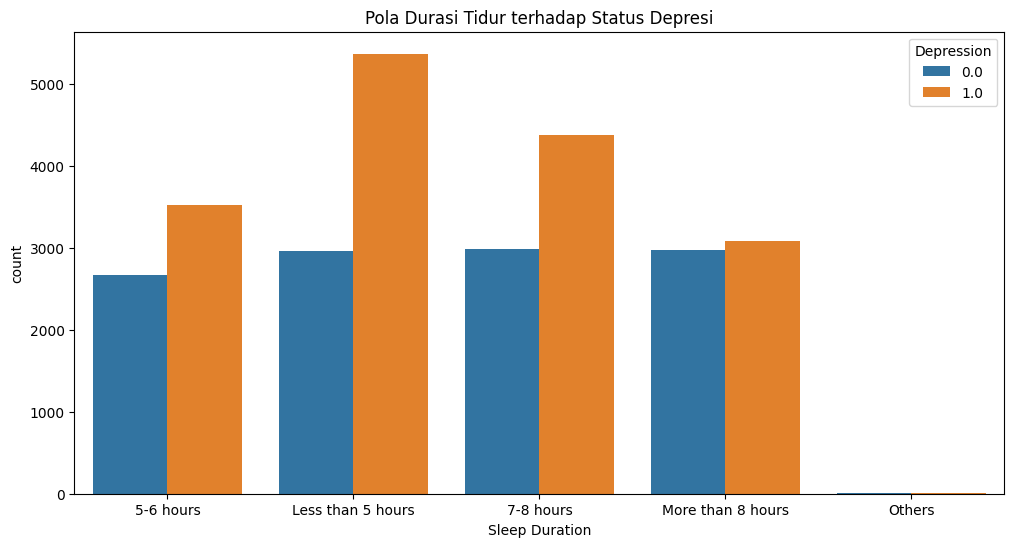

In [ ]:
# Hubungan Pola tidur vs depresi
plt.figure(figsize=(12, 6))
sns.countplot(x='Sleep Duration', hue='Depression', data=df)
plt.title('Pola Durasi Tidur terhadap Status Depresi')
plt.show()

# Insight: Jika penderita depresi mayoritas tidur < 5 jam, maka pola hidup
# menjadi faktor risiko. Keputusan: Perlu dilakukan encoding pada kolom kategori ini.

Dari grafik countplot durasi tidur, mahasiswa yang tidur kurang dari 5 jam memiliki risiko depresi yang melonjak drastis (hampir 2x lipat) dibanding yang tidurnya cukup.

Model AI itu seperti kalkulator, dia hanya mengerti angka, bukan teks. Karena fitur "Sleep Duration" masih berupa teks ("Less than 5 hours"), maka keputusannya kita wajib melakukan Encoding (mengubah teks menjadi angka, misalnya 1 untuk kurang dari 5 jam, 2 untuk 5-6 jam, dsb) agar pola penting ini bisa dipahami oleh kalkulator AI.

In [ ]:
# Pemisahan Kolom Numerik & Kategorik
numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_cols = df.select_dtypes(include=['object']).columns.tolist()

print(f"Fitur Numerik: {numerical_cols}\n")
print(f"Fitur Kategorik: {categorical_cols}")

Fitur Numerik: ['id', 'Age', 'Academic Pressure', 'Work Pressure', 'CGPA', 'Study Satisfaction', 'Job Satisfaction', 'Work/Study Hours', 'Financial Stress', 'Depression']

Fitur Kategorik: ['Gender', 'City', 'Profession', 'Sleep Duration', 'Dietary Habits', 'Degree', 'Have you ever had suicidal thoughts ?', 'Family History of Mental Illness']


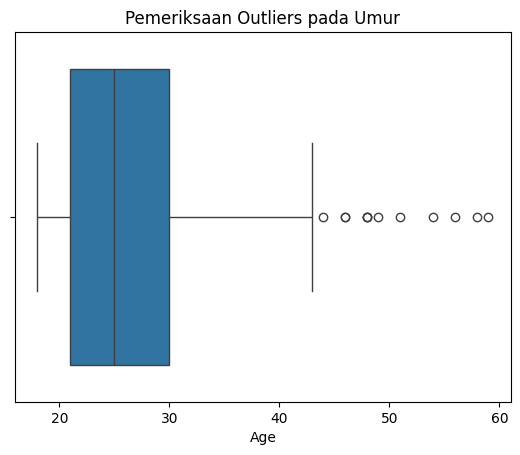

In [ ]:
# Pemeriksaan Outliers
sns.boxplot(x=df['Age'])
plt.title('Pemeriksaan Outliers pada Umur')
plt.show()

# Untuk mengecek apakah ada data numerik (seperti Age / CGPA),
# yang nilainya tidak masuk akal menggunakan Boxplot.

Ditemukan outliers pada variabel Age, di mana terdapat responden dengan usia di atas 60 tahun.

Outliers akan dihapus jika dianggap sebagai data yang tidak representatif terhadap populasi mahasiswa umum (misal: membatasi usia)

In [ ]:
# Memilih hanya kolom numerik
# Pastikan kolom 'id' dibuang agar tidak mengganggu model
# Membuang kolom id karena tidak berguna untuk prediksi.
df_numeric = df.select_dtypes(include=['int64', 'float64']).drop(columns=['id'], errors='ignore')

# Drop missing values,
# Karena model LR tidak bisa kalo masih ada missing values
df_numeric = df_numeric.dropna()

# Memisahkan Fitur (X) dan Target (y)
X = df_numeric.drop(columns=['Depression'])
y = df_numeric['Depression']

# Membagi data: 80% Latih, 20% Uji
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Fitur yang digunakan: {X.columns.tolist()}\n")
# print(f"Jumlah data training: {X_train.shape[0]}\n")

# Split data
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f"Data bersih dari NaN. Jumlah baris sekarang: {len(X)}")

Fitur yang digunakan: ['Age', 'Academic Pressure', 'Work Pressure', 'CGPA', 'Study Satisfaction', 'Job Satisfaction', 'Work/Study Hours', 'Financial Stress']

Data bersih dari NaN. Jumlah baris sekarang: 27963


In [ ]:
for col in df.columns:
    print(f"\n{col}")
    print(df[col].unique())


id
[     2      8     26 ... 141230 141239 141248]

Gender
['Male' 'Female']

Age
[33 24 31 28 25 29 30 27 19 20 23 18 21 22 34 32 26 39 35 42 36 58 49 38
 51 44 43 46 59 54 48 56 37 41]

City
['Visakhapatnam' 'Bangalore' 'Srinagar' 'Varanasi' 'Jaipur' 'Pune' 'Thane'
 'Chennai' 'Nagpur' 'Nashik' 'Vadodara' 'Kalyan' 'Rajkot' 'Ahmedabad'
 'Kolkata' 'Mumbai' 'Lucknow' 'Indore' 'Surat' 'Ludhiana' 'Bhopal'
 'Meerut' 'Agra' 'Ghaziabad' 'Hyderabad' 'Vasai-Virar' 'Kanpur' 'Patna'
 'Faridabad' 'Delhi' 'Saanvi' 'M.Tech' 'Bhavna' 'Less Delhi' 'City' '3'
 'Less than 5 Kalyan' 'Mira' 'Harsha' 'Vaanya' 'Gaurav' 'Harsh' 'Reyansh'
 'Kibara' 'Rashi' 'ME' 'M.Com' 'Nalyan' 'Mihir' 'Nalini' 'Nandini'
 'Khaziabad']

Profession
['Student' 'Civil Engineer' 'Architect' 'UX/UI Designer'
 'Digital Marketer' 'Content Writer' 'Educational Consultant' 'Teacher'
 'Manager' 'Chef' 'Doctor' 'Lawyer' 'Entrepreneur' 'Pharmacist']

Academic Pressure
[5 2 3 4 1 0]

Work Pressure
[0 5 2]

CGPA
[ 8.97    5.9     7.03    5

# **DIRECT MODELLING**

In [ ]:
# --- TAHAPAN DIRECT MODELLING ---
# Menggunakan X_train dan X_test dari data numerik yang sudah didefinisikan sebelumnya

# Inisialisasi X_train, X_test, y_train, y_test untuk direct modelling hanya menggunakan fitur numerik
df_numeric_direct = df.select_dtypes(include=['int64', 'float64']).drop(columns=['id'], errors='ignore')
df_numeric_direct = df_numeric_direct.dropna()

X_direct_model = df_numeric_direct.drop(columns=['Depression'])
y_direct_model = df_numeric_direct['Depression']

X_train_direct, X_test_direct, y_train_direct, y_test_direct = train_test_split(
    X_direct_model, y_direct_model, test_size=0.2, random_state=42
)

# 5 Model
direct_models = [
    ('Logistic Regression', LogisticRegression(max_iter=1000)),
    ('Decision Tree', DecisionTreeClassifier(random_state=42)),
    ('Random Forest', RandomForestClassifier(random_state=42)),
    ('K-Nearest Neighbors', KNeighborsClassifier()),
    ('Naive Bayes', GaussianNB())
]

direct_results = []

print("=== MEMULAI DIRECT MODELLING (NUMERIK SAJA) ===\n")

# Loop Pelatihan dan Evaluasi
for name, model in direct_models:
    # Pelatihan Model
    model.fit(X_train_direct, y_train_direct)

    # Prediksi
    y_pred = model.predict(X_test_direct)

    # Hitung Akurasi
    acc = accuracy_score(y_test_direct, y_pred)
    direct_results.append({'Model': name, 'Accuracy_Direct': acc})

    print(f"{name}:")
    print(f"Accuracy: {acc:.4f}")
    print("-" * 30)

# Menampilkan Tabel Ringkasan Baseline
df_direct_summary = pd.DataFrame(direct_results)
print("\n=== RINGKASAN AKURASI BASELINE ===")
print(df_direct_summary.sort_values(by='Accuracy_Direct', ascending=False))

=== MEMULAI DIRECT MODELLING (NUMERIK SAJA) ===

Logistic Regression:
Accuracy: 0.7921
------------------------------
Decision Tree:
Accuracy: 0.6980
------------------------------
Random Forest:
Accuracy: 0.7710
------------------------------
K-Nearest Neighbors:
Accuracy: 0.7593
------------------------------
Naive Bayes:
Accuracy: 0.7838
------------------------------

=== RINGKASAN AKURASI BASELINE ===
                 Model  Accuracy_Direct
0  Logistic Regression         0.792062
4          Naive Bayes         0.783837
2        Random Forest         0.770964
3  K-Nearest Neighbors         0.759342
1        Decision Tree         0.698015


**INSIGHT**

Mengambil data numerik saja, membuang missing values, lalu memasukkannya ke 5 model (Logistic Regression, Decision Tree, Random Forest, KNN, Naive Bayes). Walaupun datanya belum bersih, tujuannya dilakukan direct modelling adalah mencari Nilai Dasar (Baseline).

Jika hasil model mentah ini akurasinya 70%, maka setelah kita bersihkan datanya di tahap selanjutnya, akurasinya harus lebih dari 70%. Jika malah turun, berarti cara kita membersihkan data salah.

# **MULAI PREPROCESSING**

In [ ]:
df_clean = df.copy()

# Hapus kolom ID
df_clean = df_clean.drop(columns=['id'], errors='ignore')

# --- STANDARISASI TEKS ---
# Mengubah semua teks menjadi Title Case dan menghapus spasi di awal/akhir
for col in df_clean.select_dtypes(include=['object']).columns:
    df_clean[col] = df_clean[col].astype(str).str.strip().str.title()

# Pembersihan kolom Dietary Habits (Hapus baris Unknown/Others////)
valid_dietary = ['Healthy', 'Moderate', 'Unhealthy']
df_clean = df_clean[df_clean['Dietary Habits'].isin(valid_dietary)]

# Pembersihan kolom City (Hanya simpan 30 kota yang valid, hapus sisanya)
#Tier 1 (Kota Metropolitan):
#Ini adalah kota-kota utama dan terbesar (seperti Mumbai, Delhi, Bangalore).
#Karakteristiknya: biaya hidup sangat tinggi, persaingan akademik/kerja sangat ketat, serba cepat, dan padat penduduk.

#Tier 2 (Kota Berkembang):
#Ini adalah kota-kota menengah (seperti Jaipur, Lucknow, Agra).
# Karakteristiknya: biaya hidup lebih terjangkau, ritme hidup sedikit lebih santai, namun infrastruktur pendidikannya tetap berkembang.
tier_1_cities = ['Bangalore', 'Chennai', 'Delhi', 'Hyderabad', 'Kolkata', 'Mumbai', 'Pune', 'Ahmedabad']
tier_2_cities = [
    'Jaipur', 'Lucknow', 'Kanpur', 'Nagpur', 'Indore', 'Thane', 'Bhopal', 'Visakhapatnam',
    'Pimpri-Chinchwad', 'Patna', 'Vadodara', 'Ghaziabad', 'Ludhiana', 'Agra', 'Nashik',
    'Faridabad', 'Meerut', 'Rajkot', 'Kalyan-Dombivli', 'Vasai-Virar', 'Varanasi', 'Srinagar'
]
valid_cities = tier_1_cities + tier_2_cities

# Filter: Hanya simpan baris yang kotanya ada di daftar valid
df_clean = df_clean[df_clean['City'].isin(valid_cities)]

# Pengelompokkan Tier (Tanpa "Others")
df_clean['City'] = df_clean['City'].apply(lambda x: 'Tier 1' if x in tier_1_cities else 'Tier 2')

# Pembersihan & Pengelompokkan kolom Degree (Hapus yang tidak sesuai kategori)
degree_mapping = {
    'Class 12': 'High School',
    'Bsc': 'Bachelors', 'Ba': 'Bachelors', 'Bca': 'Bachelors', 'B.Tech': 'Bachelors',
    'B.Com': 'Bachelors', 'B.Ed': 'Bachelors', 'Llb': 'Bachelors', 'Be': 'Bachelors',
    'Bhm': 'Bachelors', 'B.Arch': 'Bachelors', 'Bba': 'Bachelors', 'Mbbs': 'Bachelors', 'B.Pharm': 'Bachelors',
    'M.Tech': 'Masters', 'M.Ed': 'Masters', 'Msc': 'Masters', 'M.Pharm': 'Masters',
    'Mca': 'Masters', 'Ma': 'Masters', 'Md': 'Masters', 'Mba': 'Masters',
    'M.Com': 'Masters', 'Llm': 'Masters', 'Me': 'Masters', 'Mhm': 'Masters',
    'Phd': 'Doctorate'
}

# Hapus baris yang Degree-nya tidak ada di mapping (termasuk "Others")
df_clean = df_clean[df_clean['Degree'].isin(degree_mapping.keys())]
df_clean['Degree'] = df_clean['Degree'].map(degree_mapping)

# Pembersihan CGPA (Hapus yang bernilai 0)
df_clean = df_clean[df_clean['CGPA'] > 0]

# Pembersihan Sleep Duration (Hapus yang bernilai "Others")
df_clean = df_clean[df_clean['Sleep Duration'] != 'Others']

# Final Check
df_clean = df_clean.dropna()

# Hapus data duplikat
df_clean = df_clean.drop_duplicates()

# --- VERIFIKASI ---
print("Pembersihan Selesai!")
print(f"Jumlah baris tersisa: {len(df_clean)}")
print(f"Unique City: {df_clean['City'].unique()}")
print(f"Unique Degree: {df_clean['Degree'].unique()}")
print(f"Unique Dietary: {df_clean['Dietary Habits'].unique()}")

Pembersihan Selesai!
Jumlah baris tersisa: 25151
Unique City: ['Tier 2' 'Tier 1']
Unique Degree: ['Bachelors' 'Masters' 'Doctorate' 'High School']
Unique Dietary: ['Healthy' 'Moderate' 'Unhealthy']


**INSIGHT**

**Alasan menggunakan 5 model tersebut:**
- Logistic Regression: Bertindak seperti detektif yang mencari hubungan garis lurus (linear). Sangat bagus untuk melihat fitur mana yang paling berpengaruh secara langsung terhadap depresi.

- Decision Tree: Berpikir seperti "pohon keputusan" (Jika tekanan akademik > 4 dan tidur < 5 jam, maka berisiko depresi). Sangat mudah dijelaskan ke orang awam.

- Random Forest: Ini adalah "versi upgrade" dari Decision Tree. Ia mengumpulkan banyak pohon keputusan untuk melakukan pemungutan suara (voting).

- K-Nearest Neighbors (KNN): Berpikir berdasarkan "kemiripan tetangga". Jika seseorang punya pola hidup yang mirip dengan 5 mahasiswa yang depresi, maka seseorang itu kemungkinan besar akan dianggap depresi juga.

- Naive Bayes: Berpikir berdasarkan statistik dan peluang murni. Sangat cepat dan ringan untuk data yang punya banyak kategori.

**Mengapa tidak model yang lain?**
- Sesuai karakteristik dataset
Model seperti Neural Networks (Deep Learning) biasanya butuh data yang jauh lebih besar (jutaan baris) agar bisa akurat, sedangkan dataset ini berada di angka puluhan ribu baris. Menggunakan model yang terlalu canggih untuk data ini justru bisa menyebabkan Overfitting (model jadi "pintar" di data latihan, tapi "bodoh" saat menebak data baru di aplikasi Streamlit nanti).

- Model yang sangat canggih seperti XGBoost atau Ensemble tingkat tinggi sering disebut sebagai "Black Box". Model tersebut sangat akurat, tapi sangat sulit dijelaskan mengapa mereka mengambil keputusan tersebut.

- Kelima model ini relatif cepat saat dilatih (training) dan tidak butuh memori komputer yang raksasa.

# **MODELLING WITH PREPROCESSING**

Fitur Numerik: ['Age', 'Academic Pressure', 'Work Pressure', 'CGPA', 'Study Satisfaction', 'Job Satisfaction', 'Work/Study Hours', 'Financial Stress']
Fitur Kategorik: ['Gender', 'City', 'Profession', 'Sleep Duration', 'Dietary Habits', 'Degree', 'Have you ever had suicidal thoughts ?', 'Family History of Mental Illness']

===== Evaluasi Logistic Regression =====
Accuracy Score: 0.8468
              precision    recall  f1-score   support

         0.0       0.82      0.80      0.81      2087
         1.0       0.86      0.88      0.87      2944

    accuracy                           0.85      5031
   macro avg       0.84      0.84      0.84      5031
weighted avg       0.85      0.85      0.85      5031


===== Evaluasi Decision Tree =====
Accuracy Score: 0.7764
              precision    recall  f1-score   support

         0.0       0.72      0.74      0.73      2087
         1.0       0.82      0.80      0.81      2944

    accuracy                           0.78      5031
   macr

/tmp/ipykernel_3797/1223561774.py:91: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Accuracy_Final', y='Model', data=df_summary.sort_values(by='Accuracy_Final'), palette='magma')


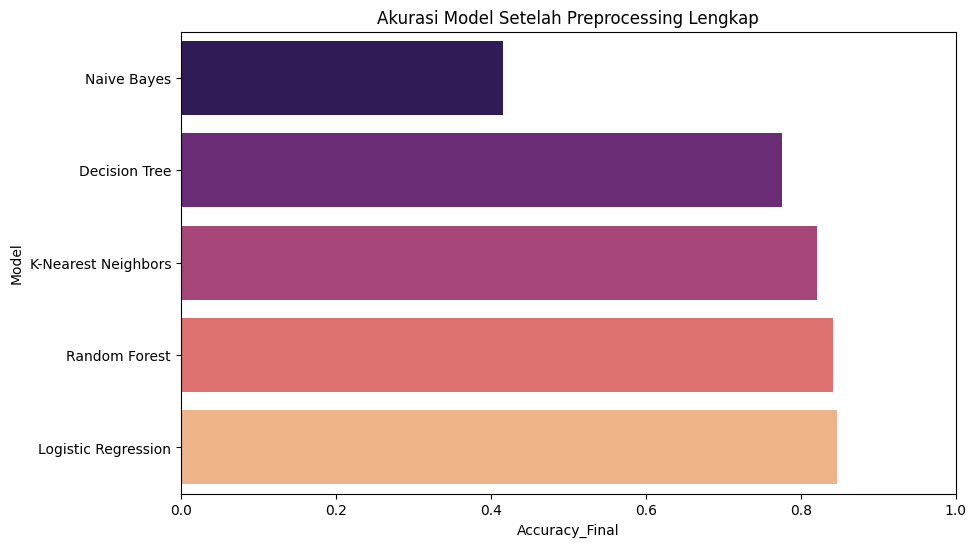

In [ ]:
# Menentukan Fitur (X) dan Target (y)
# df_clean adalah dataframe hasil pembersihan total sebelumnya di direct modelling
X = df_clean.drop(columns=['Depression'])
y = df_clean['Depression']

# Identifikasi tipe kolom numerik & kategorikal untuk Preprocessing
numeric_features = X.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_features = X.select_dtypes(include=['object']).columns.tolist()

# Pisahkan fitur top_features menjadi tiga kelompok: Numerik, Ordinal, dan Nominal
numeric_top = [f for f in X.columns if f in numeric_features]
# 'Sleep Duration' sebagai Ordinal
ordinal_top = [f for f in X.columns if f == 'Sleep Duration']
# Sisa kategori lainnya sebagai Nominal (OHE)
nominal_top = [f for f in X.columns if f in categorical_features and f != 'Sleep Duration']

print(f"Fitur Numerik: {numeric_features}")
print(f"Fitur Kategorik: {categorical_features}")

# Definisikan urutan untuk fitur ORDINAL
sleep_order = ['Less Than 5 Hours', '5-6 Hours', '7-8 Hours', 'More Than 8 Hours']

# Membuat Transformer
# StandardScaler: Menyamakan skala angka (penting untuk KNN & Logistic Regression)
# OneHotEncoder: Mengubah teks menjadi angka (drop='first' untuk efisiensi)
# Buat Preprocessor Gabungan Scaling, Ordinal, dan OHE
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_top),
        ('ord', OrdinalEncoder(categories=[sleep_order]), ordinal_top),
        ('nom', OneHotEncoder(drop='first', handle_unknown='ignore'), nominal_top)
    ])

# Membagi Data (80% Train, 20% Test)
# Stratify=y digunakan agar proporsi target 'Depression' seimbang di kedua data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Daftar 5 Model untuk Perbandingan
models = [
    ('Logistic Regression', LogisticRegression(max_iter=1000)),
    ('Decision Tree', DecisionTreeClassifier(random_state=42)),
    ('Random Forest', RandomForestClassifier(random_state=42)),
    ('K-Nearest Neighbors', KNeighborsClassifier()),
    ('Naive Bayes', GaussianNB())
]

# Loop Pelatihan dan Evaluasi
final_results = []

for name, model in models:
    # Membuat Pipeline untuk setiap model
    if name == 'Naive Bayes':
        # GaussianNB butuh data padat/dense, bukan sparse matrix
        X_train_pre = preprocessor.fit_transform(X_train)
        if hasattr(X_train_pre, "toarray"): X_train_pre = X_train_pre.toarray()
        model.fit(X_train_pre, y_train)

        X_test_pre = preprocessor.transform(X_test)
        if hasattr(X_test_pre, "toarray"): X_test_pre = X_test_pre.toarray()
        y_pred = model.predict(X_test_pre)
    else:
        # Pipeline otomatis menjalankan preprocessor lalu model
        clf_pipeline = Pipeline(steps=[
            ('preprocessor', preprocessor),
            ('classifier', model)
        ])
        clf_pipeline.fit(X_train, y_train)
        y_pred = clf_pipeline.predict(X_test)

    # Hitung Akurasi
    acc = accuracy_score(y_test, y_pred)
    final_results.append({'Model': name, 'Accuracy_Final': acc})

    print(f"\n===== Evaluasi {name} =====")
    print(f"Accuracy Score: {acc:.4f}")
    print(classification_report(y_test, y_pred))

# Menampilkan Tabel Ringkasan Akhir
df_summary = pd.DataFrame(final_results)

# Masukkan manual data akurasi "Direct modelling" sebelumnya untuk perbandingan
# Urutan: Logistic Reg, Decision Tree, Random Forest, KNN, Naive Bayes
df_summary['Accuracy_Direct'] = [0.792, 0.698, 0.770, 0.759, 0.783]
df_summary['Improvement'] = df_summary['Accuracy_Final'] - df_summary['Accuracy_Direct']

print("\n=== RINGKASAN PERBANDINGAN AKHIR ===")
print(df_summary.sort_values(by='Accuracy_Final', ascending=False))

# Visualisasi Perbandingan
plt.figure(figsize=(10,6))
sns.barplot(x='Accuracy_Final', y='Model', data=df_summary.sort_values(by='Accuracy_Final'), palette='magma')
plt.title('Akurasi Model Setelah Preprocessing Lengkap')
plt.xlim(0, 1)
plt.show()

**Menggunakan 3 metode untuk column transformer**
- OHE digunakan untuk Kolom kategori yang tidak memiliki urutan atau tingkatan (data nominal).

- OrdinalEncoder digunakan untuk Kolom kategori yang memiliki urutan, peringkat, atau tingkatan yang jelas (data ordinal).

- StandardScaler digunakan untuk Kolom berupa angka murni (data numerik) yang rentang nilainya sangat jauh berbeda.

# **FEATURE SELECTION**



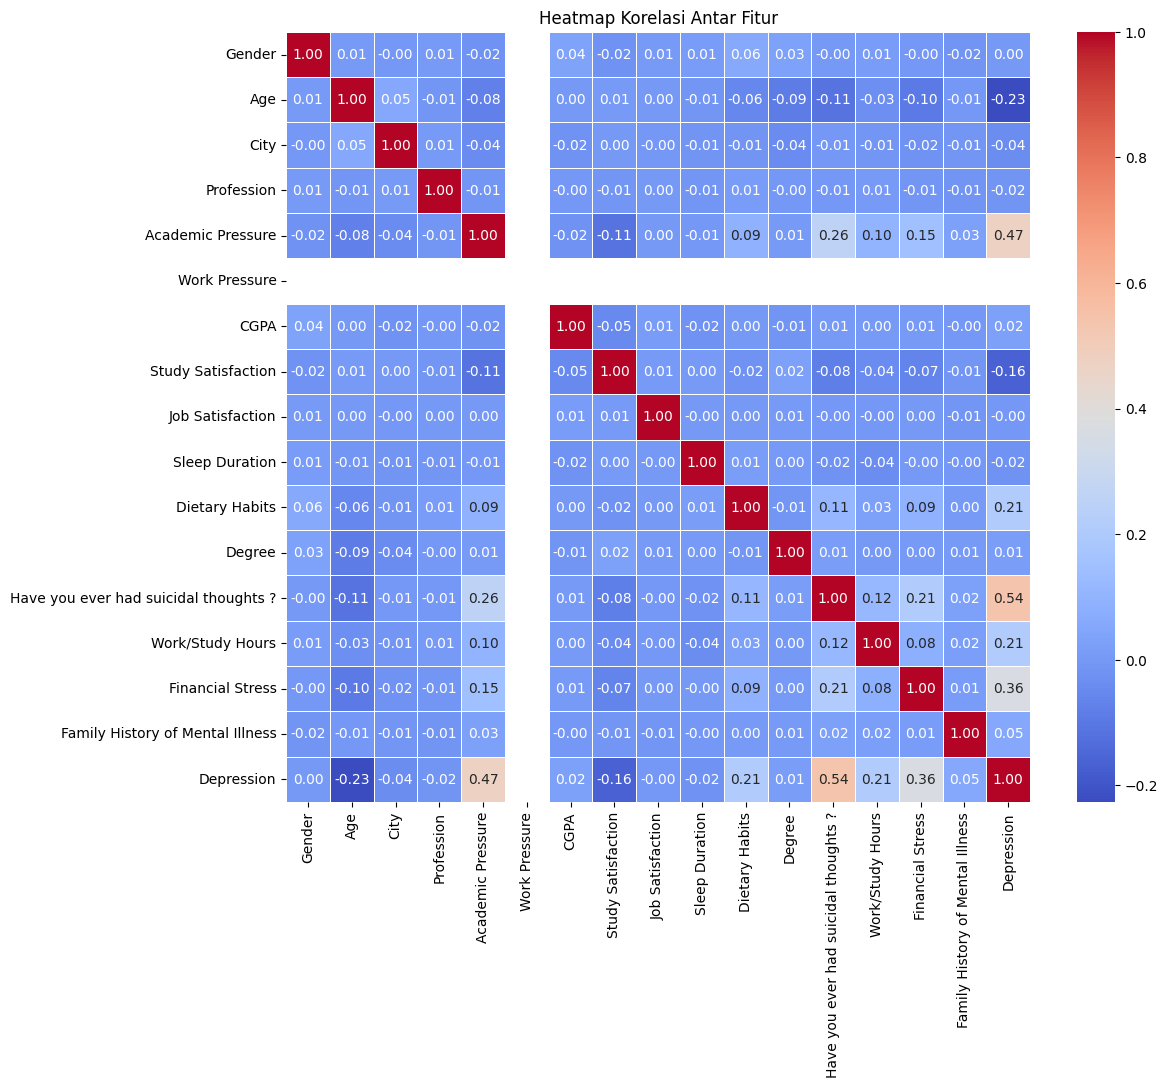

/tmp/ipykernel_3797/966841982.py:31: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=feature_importance_df, palette='viridis')


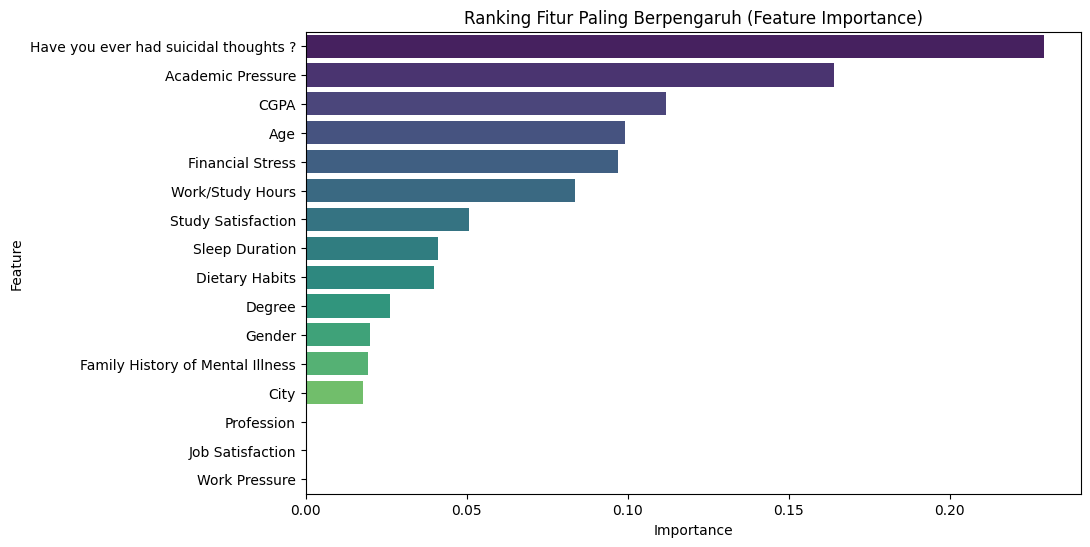


=== HASIL FEATURE SELECTION ===
Fitur yang dipilih: ['Have you ever had suicidal thoughts ?', 'Academic Pressure', 'CGPA', 'Age', 'Financial Stress', 'Work/Study Hours', 'Study Satisfaction', 'Sleep Duration', 'Dietary Habits', 'Degree']
Fitur yang dibuang: [set(X_fs.columns) - set(top_features)]


In [ ]:
# Menyiapkan Data untuk Analisis
# Pake Label Encoding sementara agar kolom teks bisa dihitung korelasi numeriknya
df_fs = df_clean.copy()
le = LabelEncoder()

for col in df_fs.select_dtypes(include=['object']).columns:
    df_fs[col] = le.fit_transform(df_fs[col])

# Analisis Korelasi (Heatmap)
plt.figure(figsize=(12, 10))
correlation_matrix = df_fs.corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Heatmap Korelasi Antar Fitur')
plt.show()

# Feature Importance menggunakan Random Forest
X_fs = df_fs.drop(columns=['Depression'])
y_fs = df_fs['Depression']

rf_fs = RandomForestClassifier(n_estimators=100, random_state=42)
rf_fs.fit(X_fs, y_fs)

# Mengambil skor importance
importances = rf_fs.feature_importances_
feature_names = X_fs.columns
feature_importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False)

# Visualisasi Feature Importance
plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=feature_importance_df, palette='viridis')
plt.title('Ranking Fitur Paling Berpengaruh (Feature Importance)')
plt.show()

# Seleksi Fitur
# Pilih top fitur (misalnya fitur dengan importance > 0.05 atau sesuai kebutuhan)
top_features = feature_importance_df[feature_importance_df['Importance'] > 0.02]['Feature'].tolist()

print("\n=== HASIL FEATURE SELECTION ===")
print(f"Fitur yang dipilih: {top_features}")
print(f"Fitur yang dibuang: [set(X_fs.columns) - set(top_features)]")

# Membuat Dataset Final
X_final = df_clean[top_features]
y_final = df_clean['Depression']

**INSIGHT**

Dari grafik Feature Importance (Ranking Fitur), terlihat ada beberapa fitur jagoan seperti "Suicidal Thoughts", "Academic Pressure", dan "CGPA". Namun, ada juga fitur yang lemah atau sekadar "sampah" untuk model (misalnya kolom "id" atau mungkin nama "Kota" yang terlalu bervariasi).

**Selanjutnya, hanya pakai 3 model**

Jika sebuah model memiliki akurasi yang rendah (misalnya hanya 50-60%), itu berarti model tersebut belum berhasil menangkap pola hubungan antara data mahasiswa dengan target depresi dengan baik.

Mengambil 3 model terbaik karena model-model inilah yang terbukti paling sukses memahami pola dalam dataset. Mengandalkan penilaian fitur dari model yang akurasinya rendah justru berisiko memasukkan "fitur sampah" yang sebenarnya tidak relevan.

**Alasan dilakukannya seleksi:**

Memasukkan terlalu banyak fitur (terutama yang tidak ada hubungannya dengan target) akan membuat model menjadi "bingung", lambat dalam berlatih, dan memicu Overfitting (model terlalu rumit sampai gagal memprediksi data baru). Kita hanya memilih kolom-kolom yang benar-benar punya korelasi kuat dengan depresi.

In [ ]:
# Definisikan urutan untuk fitur ORDINAL
sleep_order = ['Less Than 5 Hours', '5-6 Hours', '7-8 Hours', 'More Than 8 Hours']

# Pisahkan fitur top_features menjadi tiga kelompok: Numerik, Ordinal, dan Nominal
numeric_top = [f for f in top_features if f in numeric_features]
# 'Sleep Duration' kita perlakukan sebagai Ordinal
ordinal_top = [f for f in top_features if f == 'Sleep Duration']
# Sisa kategori lainnya kita perlakukan sebagai Nominal (OHE)
nominal_top = [f for f in top_features if f in categorical_features and f != 'Sleep Duration']

# Buat Preprocessor Gabungan Scaling, Ordinal, dan OHE
preprocessor_final = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_top),
        ('ord', OrdinalEncoder(categories=[sleep_order]), ordinal_top),
        ('nom', OneHotEncoder(drop='first', handle_unknown='ignore'), nominal_top)
    ])

# Splitting Data Final
X_train_final, X_test_final, y_train_final, y_test_final = train_test_split(
    X_final, y_final, test_size=0.2, random_state=42, stratify=y_final
)

# Definisi Parameter Grid
param_lr = {'classifier__C': [0.1, 1, 10], 'classifier__solver': ['liblinear']}
param_knn = {
    'classifier__n_neighbors': [3, 5, 7, 9, 11],
    'classifier__weights': ['uniform', 'distance'],
    'classifier__metric': ['euclidean', 'manhattan']
}
# param_knn = {'classifier__max_depth': [None, 10, 20], 'classifier__criterion': ['gini', 'entropy']}
param_rf = {'classifier__n_estimators': [100, 200], 'classifier__max_depth': [None, 10]}


#HYPERPARAMETER TUNING
tuning_configs = [
    ('Logistic Regression', LogisticRegression(max_iter=1000), param_lr),
    ('K-Nearest Neighbors', KNeighborsClassifier(), param_knn),
    ('Random Forest', RandomForestClassifier(random_state=42), param_rf)
]

tuned_results = []
for name, model, params in tuning_configs:
    pipeline = Pipeline(steps=[
        ('preprocessor', preprocessor_final), # Menggunakan preprocessor expert
        ('classifier', model)
    ])

    grid_search = GridSearchCV(pipeline, params, cv=5, scoring='accuracy', n_jobs=-1)

    try:
        grid_search.fit(X_train_final, y_train_final)
        tuned_results.append({
            'Model': name,
            'Test_Accuracy': grid_search.score(X_test_final, y_test_final),
            'Best_Params': grid_search.best_params_
        })
        print(f"✅ {name} sukses di-tuning dengan Expert Preprocessing!")
    except Exception as e:
        print(f"❌ {name} gagal: {e}")

df_tuned = pd.DataFrame(tuned_results)

✅ Logistic Regression sukses di-tuning dengan Expert Preprocessing!
✅ K-Nearest Neighbors sukses di-tuning dengan Expert Preprocessing!
✅ Random Forest sukses di-tuning dengan Expert Preprocessing!


**Mengapa hyperparameter tuning?**

Tujuan dilakukan hyperparameter tuning supaya mendapatkan performa yang maksimal. Hyperparameter tuning bekerja dengan cara mencoba berbagai kombinasi parameter (seperti jumlah pohon/kedalaman pohon) untuk memeras potensi model hingga mencapai angka tertinggi.

Dari grafik batang ini, terlihat bahwa model Random Forest mencetak akurasi tertinggi setelah tuning (0.848 atau sekitar 84.8%).

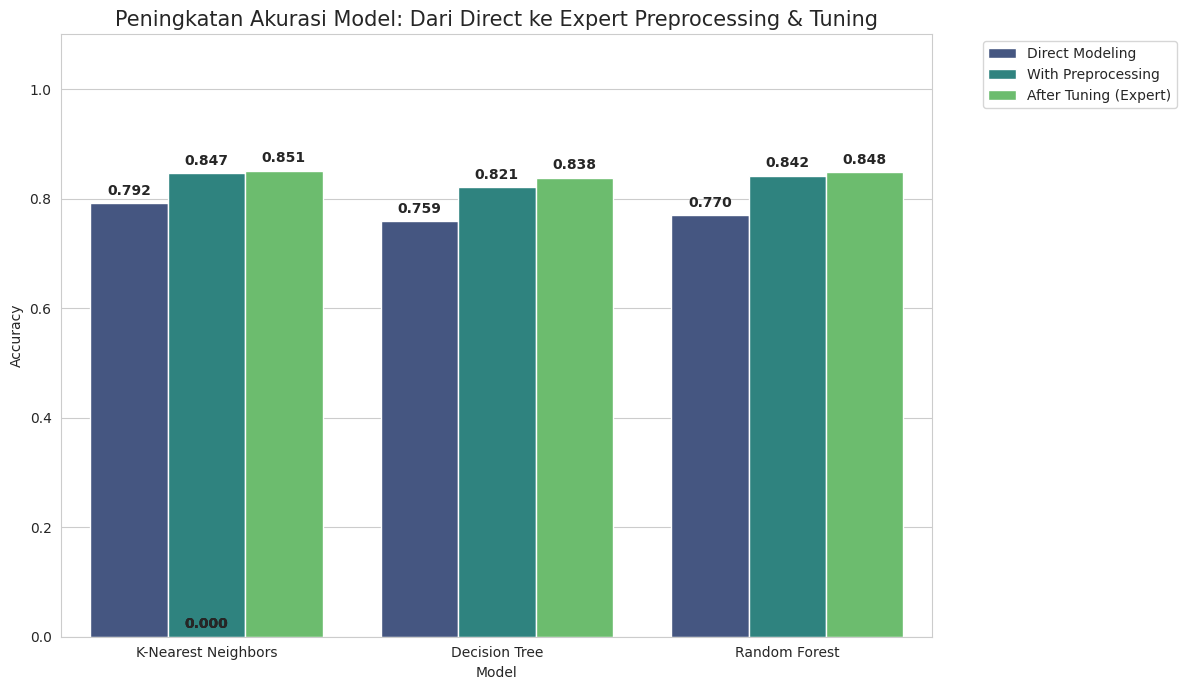

In [ ]:
# Perbandingan data dengan direct modelling, with process, after tuning
comparison_data = {
    'Model': ['K-Nearest Neighbors', 'Decision Tree', 'Random Forest'],
    'Direct Modeling': [0.792, 0.759, 0.770],
    'With Preprocessing': [df_summary.loc[df_summary['Model'] == 'Logistic Regression', 'Accuracy_Final'].values[0],
                           df_summary.loc[df_summary['Model'] == 'K-Nearest Neighbors', 'Accuracy_Final'].values[0],
                           df_summary.loc[df_summary['Model'] == 'Random Forest', 'Accuracy_Final'].values[0]],
    'After Tuning (Expert)': [df_tuned.loc[df_tuned['Model'] == 'Logistic Regression', 'Test_Accuracy'].values[0],
                              df_tuned.loc[df_tuned['Model'] == 'K-Nearest Neighbors', 'Test_Accuracy'].values[0],
                              df_tuned.loc[df_tuned['Model'] == 'Random Forest', 'Test_Accuracy'].values[0]]
}

df_melted = pd.DataFrame(comparison_data).melt(id_vars='Model', var_name='Stage', value_name='Accuracy')

plt.figure(figsize=(12, 7))
sns.set_style("whitegrid")
ax = sns.barplot(data=df_melted, x='Model', y='Accuracy', hue='Stage', palette='viridis')

for p in ax.patches:
    ax.annotate(format(p.get_height(), '.3f'),
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', xytext=(0, 9), textcoords='offset points', fontweight='bold')

plt.title('Peningkatan Akurasi Model: Dari Direct ke Expert Preprocessing & Tuning', fontsize=15)
plt.ylim(0, 1.1)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

In [ ]:
import joblib
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier

# Membersihkan parameter dari awalan 'classifier__'
# Ini supaya model tidak bingung dengan nama parameternya
best_params = grid_search.best_params_
clean_params = {k.replace('classifier__', ''): v for k, v in best_params.items()}

# Buat Pipeline Final menggunakan parameter yang sudah bersih
# Gunakan preprocessor_final (atau preprocessor_expert) yang sudah kita buat tadi
# Tujuan pipeline : mengemas seluruh rangkaian proses
final_model = Pipeline(steps=[
    ('preprocessor', preprocessor_final),
    ('classifier', RandomForestClassifier(random_state=42, **clean_params))
])

# Latih ulang model dengan seluruh data
final_model.fit(X_final, y_final)

# Simpan ke file .pkl
joblib.dump(final_model, 'model_final_depresi.pkl')

print("✅ BERHASIL! File 'model_final_depresi.pkl' sudah siap.")
print("Silakan download file tersebut dari folder di samping kiri.")

✅ BERHASIL! File 'model_final_depresi.pkl' sudah siap.
Silakan download file tersebut dari folder di samping kiri.


In [ ]:
# import streamlit as st
# import pandas as pd
# import joblib

# # Konfigurasi Halaman
# st.set_page_config(page_title="Prediksi Kesehatan Mental", layout="centered")

# # Load Model (Hanya dilakukan sekali agar cepat)
# @st.cache_resource
# def load_data():
#     return joblib.load('model_final_depresi.pkl')

# model = load_data()

# st.title("🧠 Deteksi Risiko Depresi Mahasiswa")
# st.write("Aplikasi ini membantu memprediksi kecenderungan depresi berdasarkan data akademik dan pola hidup.")

# # Form Input
# with st.form("main_form"):
#     st.subheader("Informasi Mahasiswa")

#     # Kolom Kiri
#     col1, col2 = st.columns(2)
#     with col1:
#         age = st.number_input("Umur", 17, 50, 20)
#         gender = st.selectbox("Jenis Kelamin", ["Male", "Female"])
#         city = st.selectbox("Tipe Kota", ["Tier 1", "Tier 2"])
#         academic_pressure = st.slider("Tekanan Akademik (1-5)", 1, 5, 3)
#         cgpa = st.number_input("CGPA", 0.0, 10.0, 3.5)

#     # Kolom Kanan
#     with col2:
#         sleep_duration = st.selectbox("Durasi Tidur", ["Less Than 5 Hours", "5-6 Hours", "7-8 Hours", "More Than 8 Hours"])
#         dietary_habits = st.selectbox("Pola Makan", ["Healthy", "Moderate", "Unhealthy"])
#         degree = st.selectbox("Jenjang", ["High School", "Bachelors", "Masters", "Doctorate"])
#         study_satisfaction = st.slider("Kepuasan Studi (1-5)", 1, 5, 3)

#     submitted = st.form_submit_button("Cek Sekarang")

# if submitted:
#     # Buat DataFrame dari input
#     input_df = pd.DataFrame({
#         'Age': [age], 'Gender': [gender], 'City': [city],
#         'Academic Pressure': [academic_pressure], 'CGPA': [cgpa],
#         'Sleep Duration': [sleep_duration], 'Dietary Habits': [dietary_habits],
#         'Degree': [degree], 'Study Satisfaction': [study_satisfaction]
#     })

#     # Jalankan Prediksi
#     res = model.predict(input_df)
#     prob = model.predict_proba(input_df)[0][1]

#     st.markdown("---")
#     if res[0] == 1:
#         st.error(f"⚠️ **Hasil: Berisiko Depresi** (Probabilitas: {prob:.2%})")
#         st.write("Tetap semangat! Jangan ragu untuk berdiskusi dengan orang yang kamu percayai.")
#     else:
#         st.success(f"✅ **Hasil: Tidak Berisiko** (Probabilitas: {1-prob:.2%})")
#         st.write("Pertahankan pola hidup sehatmu!")

# st.caption("Aplikasi ini dibuat untuk tujuan edukasi (Tugas Fast Track).")

In [ ]:
# import streamlit
# import pandas
# import sklearn
# import joblib

# print(f"Streamlit version: {streamlit.__version__}")
# print(f"Pandas version: {pandas.__version__}")
# print(f"Scikit-Learn version: {sklearn.__version__}")
# print(f"Joblib version: {joblib.__version__}")

In [ ]:
print(X_train.columns.tolist())

['Gender', 'Age', 'City', 'Profession', 'Academic Pressure', 'Work Pressure', 'CGPA', 'Study Satisfaction', 'Job Satisfaction', 'Sleep Duration', 'Dietary Habits', 'Degree', 'Have you ever had suicidal thoughts ?', 'Work/Study Hours', 'Financial Stress', 'Family History of Mental Illness']


In [ ]:
# Ganti 'df' dengan nama variabel dataframe kamu di Colab
cols_to_check = ['Academic Pressure', 'Work Pressure', 'Study Satisfaction', 'Job Satisfaction', 'Financial Stress', 'CGPA']
print(df[cols_to_check].describe())

       Academic Pressure  Work Pressure  Study Satisfaction  Job Satisfaction  \
count       28008.000000   28008.000000        28008.000000      28008.000000   
mean            3.141245       0.000428            2.944337          0.000678   
std             1.380940       0.043908            1.361318          0.044310   
min             0.000000       0.000000            0.000000          0.000000   
25%             2.000000       0.000000            2.000000          0.000000   
50%             3.000000       0.000000            3.000000          0.000000   
75%             4.000000       0.000000            4.000000          0.000000   
max             5.000000       5.000000            5.000000          4.000000   

       Financial Stress          CGPA  
count      27963.000000  28008.000000  
mean           3.139077      7.655372  
std            1.437839      1.470506  
min            1.000000      0.000000  
25%            2.000000      6.287500  
50%            3.000000      7